## Market Analysis & Trends:
1) Identify best-selling genres and platforms over the years  
2) Analyze the impact of publishers on sales performance  
3) Track sales trends across regions (NA, JP, EP, Otherisher)

## Business Strategy & Game Development:
- Help game developers understand what type of games sell best  
- Guide marketing strategies by targeting specific regions with high demand

## Comparative Analysis:
- Compare sales performance of different gaming platforms (PlayStation, Xbox, Wii)  
- Evaluate how different game publishers perform in various markets

---

### 🆕 What You Can Add Next
- **Top 5 Publishers Per Region** (not just top 1) — gives broader insight  
- **Platform-wise Analysis**: Which platforms dominate globally or regionally?  
- **Genre Popularity over time or by region**


In [1]:
#importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("data/vgsales.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [3]:
#looking for the ds details
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [4]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [5]:
df.isna().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
#filling the year column with the mean as its necessary for the plots
df["Year"] = df["Year"].fillna(df["Year"].mean())
df.isna().sum()

Rank             0
Name             0
Platform         0
Year             0
Genre            0
Publisher       58
NA_Sales         0
EU_Sales         0
JP_Sales         0
Other_Sales      0
Global_Sales     0
dtype: int64

In [8]:
gen_val= df["Genre"].value_counts().values
gen_val.shape

(12,)

In [9]:
year_val = df["Year"].value_counts().index
year_val = year_val.astype(int)
year_val.shape

(40,)

In [10]:
df["Year"]

0        2006.0
1        1985.0
2        2008.0
3        2009.0
4        1996.0
          ...  
16593    2002.0
16594    2003.0
16595    2008.0
16596    2010.0
16597    2003.0
Name: Year, Length: 16598, dtype: float64

In [11]:
df["Genre"]

0              Sports
1            Platform
2              Racing
3              Sports
4        Role-Playing
             ...     
16593        Platform
16594         Shooter
16595          Racing
16596          Puzzle
16597        Platform
Name: Genre, Length: 16598, dtype: object

In [12]:
"""since we need to create a plot defining the best selling genres over the year that means we need to access the genre, year, and global sales column
so we grouped them together and created a new dataframe as df2"""

grp = df.groupby(["Genre", "Year"], as_index= False).sum()
grp = grp.drop(["Name", "Platform", "Publisher", "NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Rank",], axis = 1)
df2 = pd.DataFrame(grp)

In [13]:
df2["Year"]= df2["Year"].astype(int)

In [14]:
df2

,Genre,Year,Global_Sales
0,Action,1980,0.34
1,Action,1981,14.84
2,Action,1982,6.52
3,Action,1983,2.86
4,Action,1984,1.85
...,...,...,...
396,Strategy,2012,3.33
397,Strategy,2013,6.33
398,Strategy,2014,0.99
399,Strategy,2015,1.82


In [15]:
df2["Genre"]

0        Action
1        Action
2        Action
3        Action
4        Action
         ...   
396    Strategy
397    Strategy
398    Strategy
399    Strategy
400    Strategy
Name: Genre, Length: 401, dtype: object

In [16]:
df2["Year"]

0      1980
1      1981
2      1982
3      1983
4      1984
       ... 
396    2012
397    2013
398    2014
399    2015
400    2016
Name: Year, Length: 401, dtype: int32

In [17]:
df["Genre"].value_counts().index

Index(['Action', 'Sports', 'Misc', 'Role-Playing', 'Shooter', 'Adventure',
       'Racing', 'Platform', 'Simulation', 'Fighting', 'Strategy', 'Puzzle'],
      dtype='object', name='Genre')

In [18]:
#select the row for each genre which has the highest sales
df2.loc[df2.groupby('Genre')['Global_Sales'].idxmax()].reset_index(drop=True)


,Genre,Year,Global_Sales
0,Action,2009,139.36
1,Adventure,2008,25.02
2,Fighting,2008,35.38
3,Misc,2010,96.86
4,Platform,2006,49.80
5,Puzzle,1989,37.75
6,Racing,2008,70.66
7,Role-Playing,2010,70.52
8,Shooter,2011,99.36
9,Simulation,2005,49.27


In [19]:
df2.groupby('Genre')['Global_Sales'].max() #To see maximum Global Sales per genre:

Genre
Action          139.36
Adventure        25.02
Fighting         35.38
Misc             96.86
Platform         49.80
Puzzle           37.75
Racing           70.66
Role-Playing     70.52
Shooter          99.36
Simulation       49.27
Sports          138.52
Strategy         18.46
Name: Global_Sales, dtype: float64

In [20]:
df2.groupby('Genre')['Global_Sales'].idxmax() #To see the index of the maximum Global Sales per genre

Genre
Action           30
Adventure        59
Fighting         89
Misc            123
Platform        155
Puzzle          173
Racing          225
Role-Playing    259
Shooter         298
Simulation      322
Sports          366
Strategy        382
Name: Global_Sales, dtype: int64

In [21]:
df2.groupby('Genre')['Global_Sales'].sum() #To see total Global Sales per genre

Genre
Action          1751.18
Adventure        239.04
Fighting         448.91
Misc             809.96
Platform         831.37
Puzzle           244.95
Racing           732.04
Role-Playing     927.37
Shooter         1037.37
Simulation       392.20
Sports          1330.93
Strategy         175.12
Name: Global_Sales, dtype: float64

## Identify best selling Genres over the years

In [22]:
'''First, groupby('Genre')['Global_Sales'].idxmax() gives the index (i.e., row number in your DataFrame) where each genre had its highest Global_Sales.

Then df2.loc[...] retrieves the entire rows at those indexes — so you get not just the Global_Sales value, but also the corresponding Year and Genre.'''

df3 = df2.loc[df2.groupby("Genre")["Global_Sales"].idxmax()].reset_index(drop= True)

In [23]:
df3

,Genre,Year,Global_Sales
0,Action,2009,139.36
1,Adventure,2008,25.02
2,Fighting,2008,35.38
3,Misc,2010,96.86
4,Platform,2006,49.80
5,Puzzle,1989,37.75
6,Racing,2008,70.66
7,Role-Playing,2010,70.52
8,Shooter,2011,99.36
9,Simulation,2005,49.27


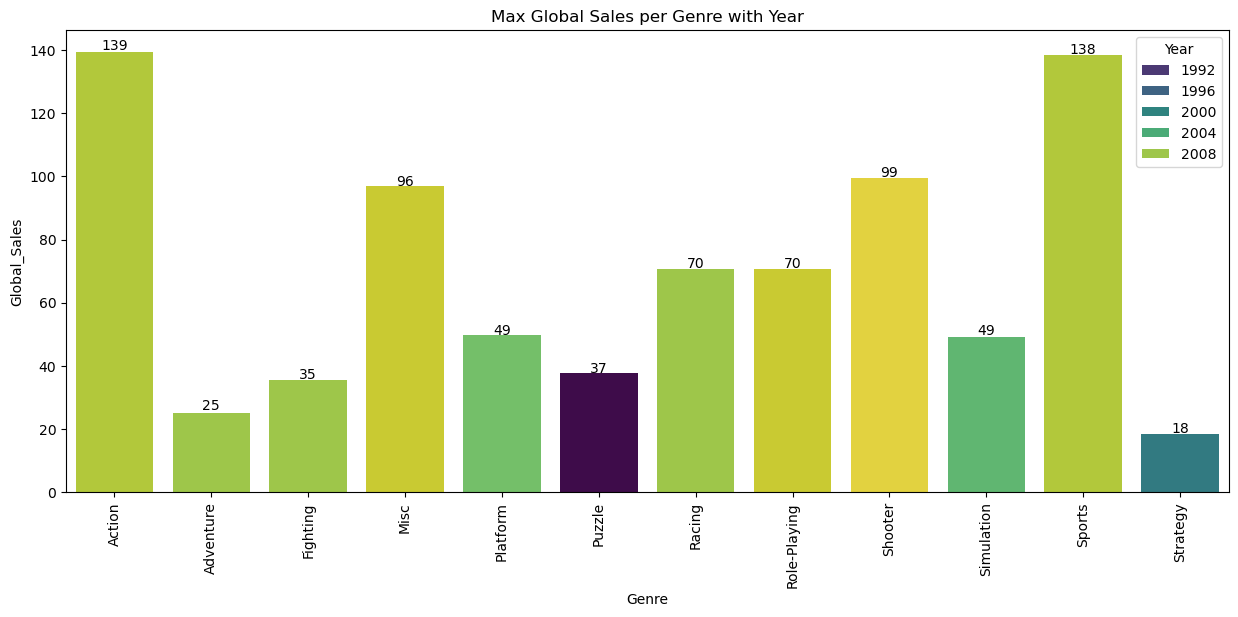

In [24]:
fig, ax = plt.subplots(figsize= (15, 6))

sns.barplot(data= df3, x= "Genre", y= "Global_Sales", hue= "Year", dodge = False, palette="viridis")
ax.set_xlabel("Genre")
ax.set_title("Max Global Sales per Genre with Year")
plt.tight_layout

for i, value in enumerate(df3["Global_Sales"].astype(int)):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.xticks(rotation = 90);

## Identify best selling platforms over the years

In [25]:
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [26]:
'''so we will make a pie chat
now since we have grouped platform with sales and year all we need to do is drop the other unnecessary column and make a fresh df
then use that to plot pie chart

or we will try to add the platform column to the df3 but I dont think we can because of shape mismatch as df3 is of 11 rows and df11 is 30 rows
wait a min ig we dont even need to drop other column and create a new df we can just use the groupbuye'd one as it creates a df so while plotting
we will just access the column that we need and leave the rest
''' 

sales_plat = df.loc[df.groupby("Platform")["Global_Sales"].idxmax()].reset_index(drop= True)

sales_plat.drop(["Rank", 'Name', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', "Other_Sales"], axis = 1, inplace= True)

top_5 = sales_plat.sort_values(by= "Global_Sales").reset_index(drop= True)

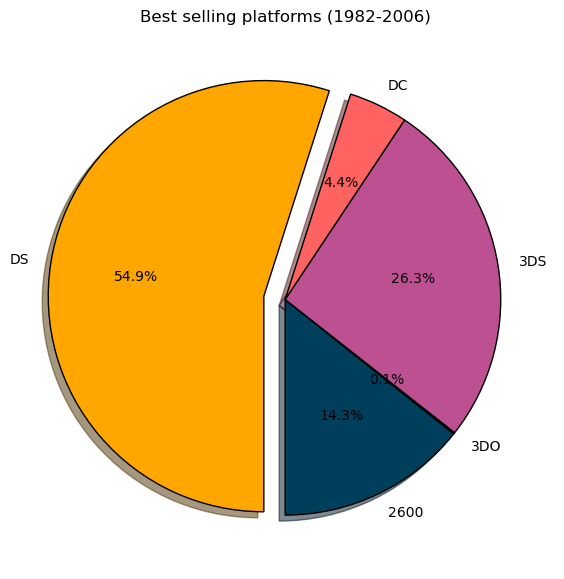

In [27]:
fig, ax = plt.subplots(figsize=(14, 7))

plt.pie(
        x= sales_plat["Global_Sales"].head(5), labels= sales_plat["Platform"].head(5),
        shadow= True,
        autopct='%1.1f%%', 
        colors=['#003f5c','#58508d','#bc5090','#ff6361','#ffa600'],
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.0},
        explode=(0, 0,0,0,0.1),
        startangle=-90
)

plt.title("Best selling platforms (1982-2006)");

## Identify top 5 best selling platforms over the years

In [28]:
top_5.tail(10)

,Platform,Year,Global_Sales
21,3DS,2013.0,14.35
22,GBA,2002.0,15.85
23,SNES,1990.0,20.61
24,PS2,2004.0,20.81
25,PS3,2013.0,21.40
26,X360,2010.0,21.82
27,DS,2006.0,30.01
28,GB,1996.0,31.37
29,NES,1985.0,40.24
30,Wii,2006.0,82.74


Text(0.5, 1.0, 'Top 5 best selling platforms')

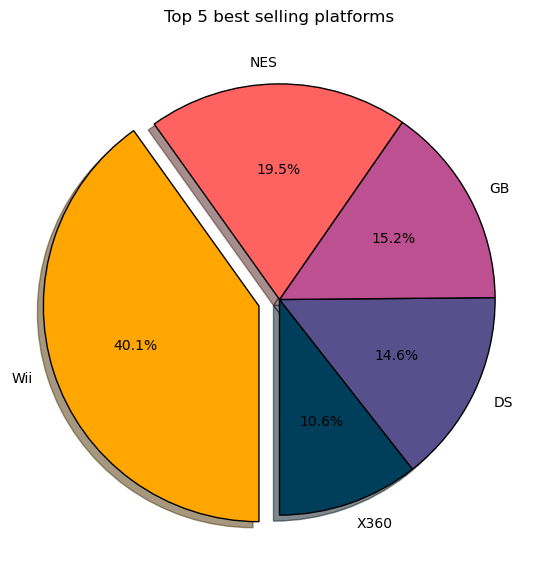

In [29]:
fig, ax = plt.subplots(figsize= (14, 7))

plt.pie(
    x= top_5['Global_Sales'].tail(5), labels= top_5['Platform'].tail(5),
        shadow= True,
        autopct='%1.1f%%', 
        colors=['#003f5c','#58508d','#bc5090','#ff6361','#ffa600'],
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.0},
        explode=(0, 0,0,0,0.1),
        startangle=-90
)

plt.title("Top 5 best selling platforms")

## Analyze the impact of publishers on sales performance


In [30]:
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [31]:
df.isna().sum()

Rank             0
Name             0
Platform         0
Year             0
Genre            0
Publisher       58
NA_Sales         0
EU_Sales         0
JP_Sales         0
Other_Sales      0
Global_Sales     0
dtype: int64

In [32]:
df["Publisher"]= df["Publisher"].fillna("Missing")

In [33]:
df.isna().sum()

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

## a) Best Publisher by Region (NA, EU, JP, Other, Global)
📌 Outcome: Tells you which publishers dominate which regions, showing regional strengths and target audience alignment.

In [34]:
region_sales= df.groupby("Publisher")[["NA_Sales", 'EU_Sales', 'JP_Sales','Other_Sales']].sum().max()
region_sales

NA_Sales       816.87
EU_Sales       418.74
JP_Sales       455.42
Other_Sales    129.77
dtype: float64

In [35]:
region = region_sales.index
region

Index(['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'], dtype='object')

In [36]:
max_region_sales= region_sales.values
max_region_sales

array([816.87, 418.74, 455.42, 129.77])

In [37]:
top_publishers= df.groupby("Publisher")[["NA_Sales", 'EU_Sales', 'JP_Sales','Other_Sales']].sum().idxmax()
top_publishers

NA_Sales              Nintendo
EU_Sales              Nintendo
JP_Sales              Nintendo
Other_Sales    Electronic Arts
dtype: object

In [38]:
best_publisher_region = pd.DataFrame({'max_sales' : max_region_sales, 'region' : region, 'publishers' : top_publishers.values})
best_publisher_region

,max_sales,region,publishers
0,816.87,NA_Sales,Nintendo
1,418.74,EU_Sales,Nintendo
2,455.42,JP_Sales,Nintendo
3,129.77,Other_Sales,Electronic Arts


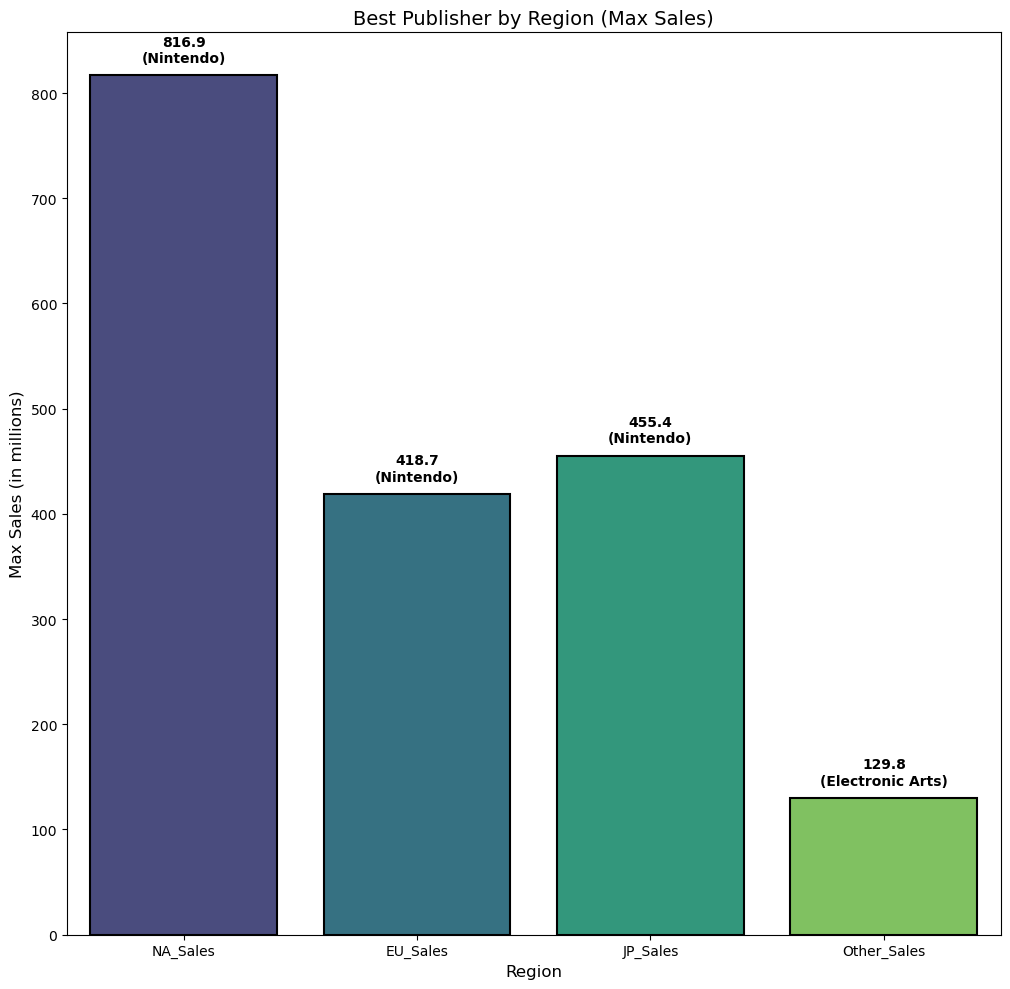

In [39]:
fig, ax = plt.subplots(figsize= (10, 10))

sns.barplot(
        data= best_publisher_region,
        x= region, 
        y= max_region_sales,
        hue= region,
        palette="viridis",  
        edgecolor='black',  
        linewidth=1.5
    )

for i, row in best_publisher_region.iterrows():
    ax.text(
        i, row['max_sales'] + 10,
        f"{row['max_sales']:.1f}\n({row['publishers']})",
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.title("Best Publisher by Region (Max Sales)", fontsize=14)
plt.xlabel("Region", fontsize=12)
plt.tight_layout()
plt.ylabel("Max Sales (in millions)", fontsize=12);

## b) Top 10 publishers with most games released

In [40]:
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [41]:
games = df["Publisher"].value_counts()
games.head(10).index

Index(['Electronic Arts', 'Activision', 'Namco Bandai Games', 'Ubisoft',
       'Konami Digital Entertainment', 'THQ', 'Nintendo',
       'Sony Computer Entertainment', 'Sega', 'Take-Two Interactive'],
      dtype='object', name='Publisher')

In [42]:
games.head(10).values

array([1351,  975,  932,  921,  832,  715,  703,  683,  639,  413],
      dtype=int64)

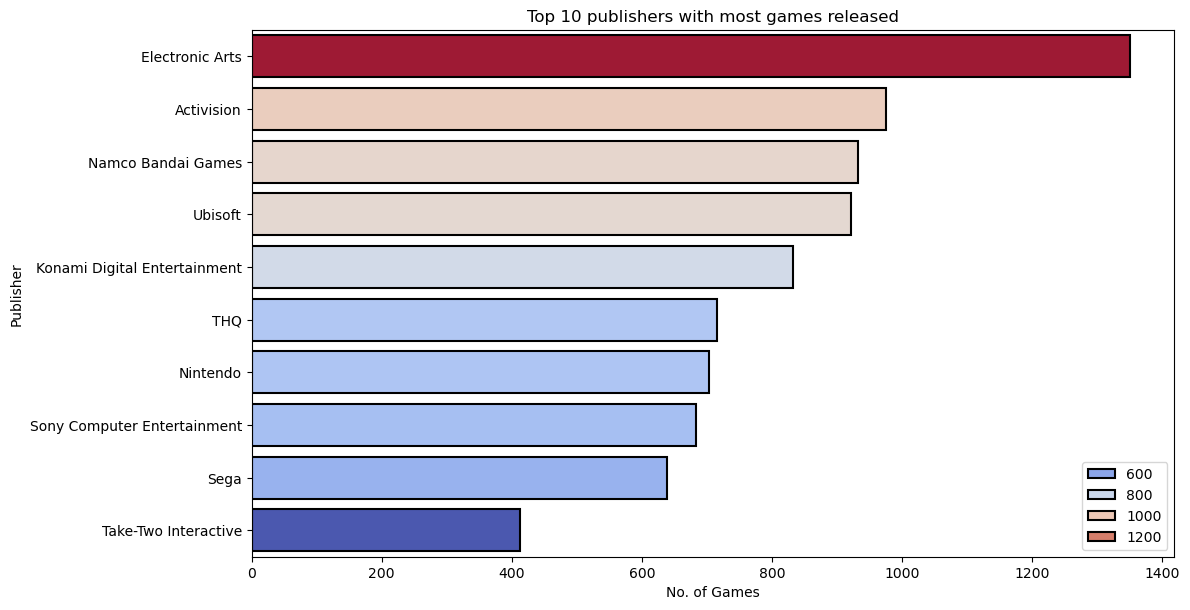

In [43]:
fig, ax = plt.subplots(figsize= (12,6))

sns.barplot(
    y= games.head(10).index, 
    x= games.head(10).values,
    hue= games.head(10).values,
    palette= "coolwarm",
    edgecolor='black',  
    linewidth=1.5
    )

ax.set_xlabel("No. of Games")
plt.tight_layout()
plt.title("Top 10 publishers with most games released");

## C) Number of game releases per year

In [44]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [45]:
df["Year"].astype(int).value_counts().head().reset_index()

,Year,count
0,2009,1431
1,2008,1428
2,2006,1279
3,2010,1259
4,2007,1202


In [46]:
game_releases_per_year = df["Year"].value_counts().sort_index()
game_releases_per_year.head()

Year
1980.0     9
1981.0    46
1982.0    36
1983.0    17
1984.0    14
Name: count, dtype: int64

In [47]:
year_releases = game_releases_per_year.index
year_releases

Index([            1980.0,             1981.0,             1982.0,
                   1983.0,             1984.0,             1985.0,
                   1986.0,             1987.0,             1988.0,
                   1989.0,             1990.0,             1991.0,
                   1992.0,             1993.0,             1994.0,
                   1995.0,             1996.0,             1997.0,
                   1998.0,             1999.0,             2000.0,
                   2001.0,             2002.0,             2003.0,
                   2004.0,             2005.0,             2006.0,
       2006.4064433147546,             2007.0,             2008.0,
                   2009.0,             2010.0,             2011.0,
                   2012.0,             2013.0,             2014.0,
                   2015.0,             2016.0,             2017.0,
                   2020.0],
      dtype='float64', name='Year')

In [48]:
game_releases = game_releases_per_year.values
game_releases

array([   9,   46,   36,   17,   14,   14,   21,   16,   15,   17,   16,
         41,   43,   60,  121,  219,  263,  289,  379,  338,  349,  482,
        829,  775,  763,  941, 1008,  271, 1202, 1428, 1431, 1259, 1139,
        657,  546,  582,  614,  344,    3,    1], dtype=int64)

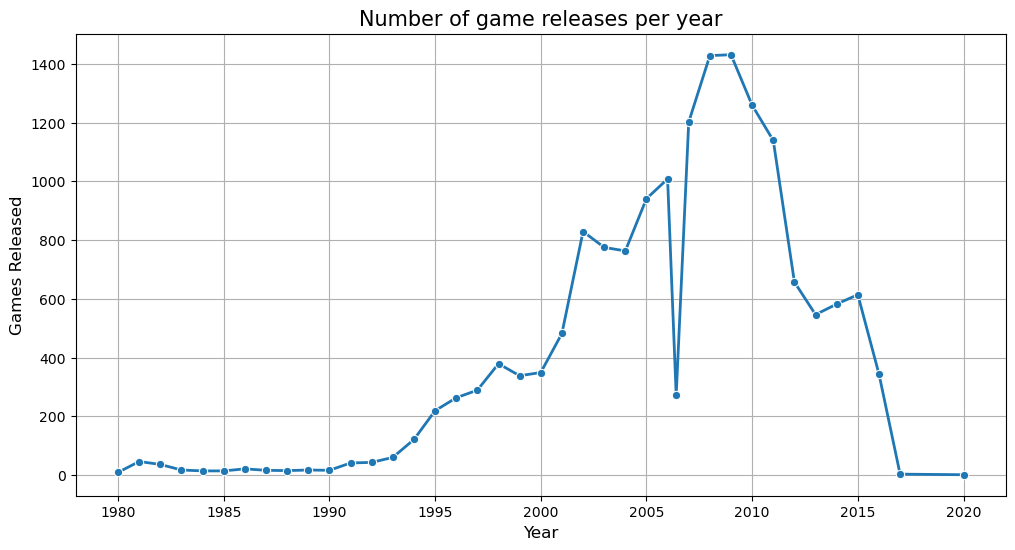

In [49]:
fig, ax = plt.subplots(figsize= (12, 6))

sns.lineplot(
    x= year_releases, 
    y= game_releases,
    linewidth= 2.0,
    marker= 'o'
    )
ax.set_ylabel("Games Released", size= 12)
ax.set_xlabel("Year", size= 12)
plt.title("Number of game releases per year", size= 15)
plt.grid();

## d) Trending Genre over the years

In [50]:
df["Year"] = df["Year"].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16598 non-null  int32  
 4   Genre         16598 non-null  object 
 5   Publisher     16598 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(5), int32(1), int64(1), object(4)
memory usage: 1.3+ MB


In [51]:
y_g = df.groupby(["Year","Genre"])["Genre"].value_counts().reset_index()
y_g.head(8)

,Year,Genre,count
0,1980,Action,1
1,1980,Fighting,1
2,1980,Misc,4
3,1980,Shooter,2
4,1980,Sports,1
5,1981,Action,25
6,1981,Platform,3
7,1981,Puzzle,2


In [52]:
top_genre_per_year= y_g.loc[y_g.groupby("Year")["count"].idxmax()].reset_index(drop= True)
top_genre_per_year.head()

,Year,Genre,count
0,1980,Misc,4
1,1981,Action,25
2,1982,Action,18
3,1983,Action,7
4,1984,Puzzle,3


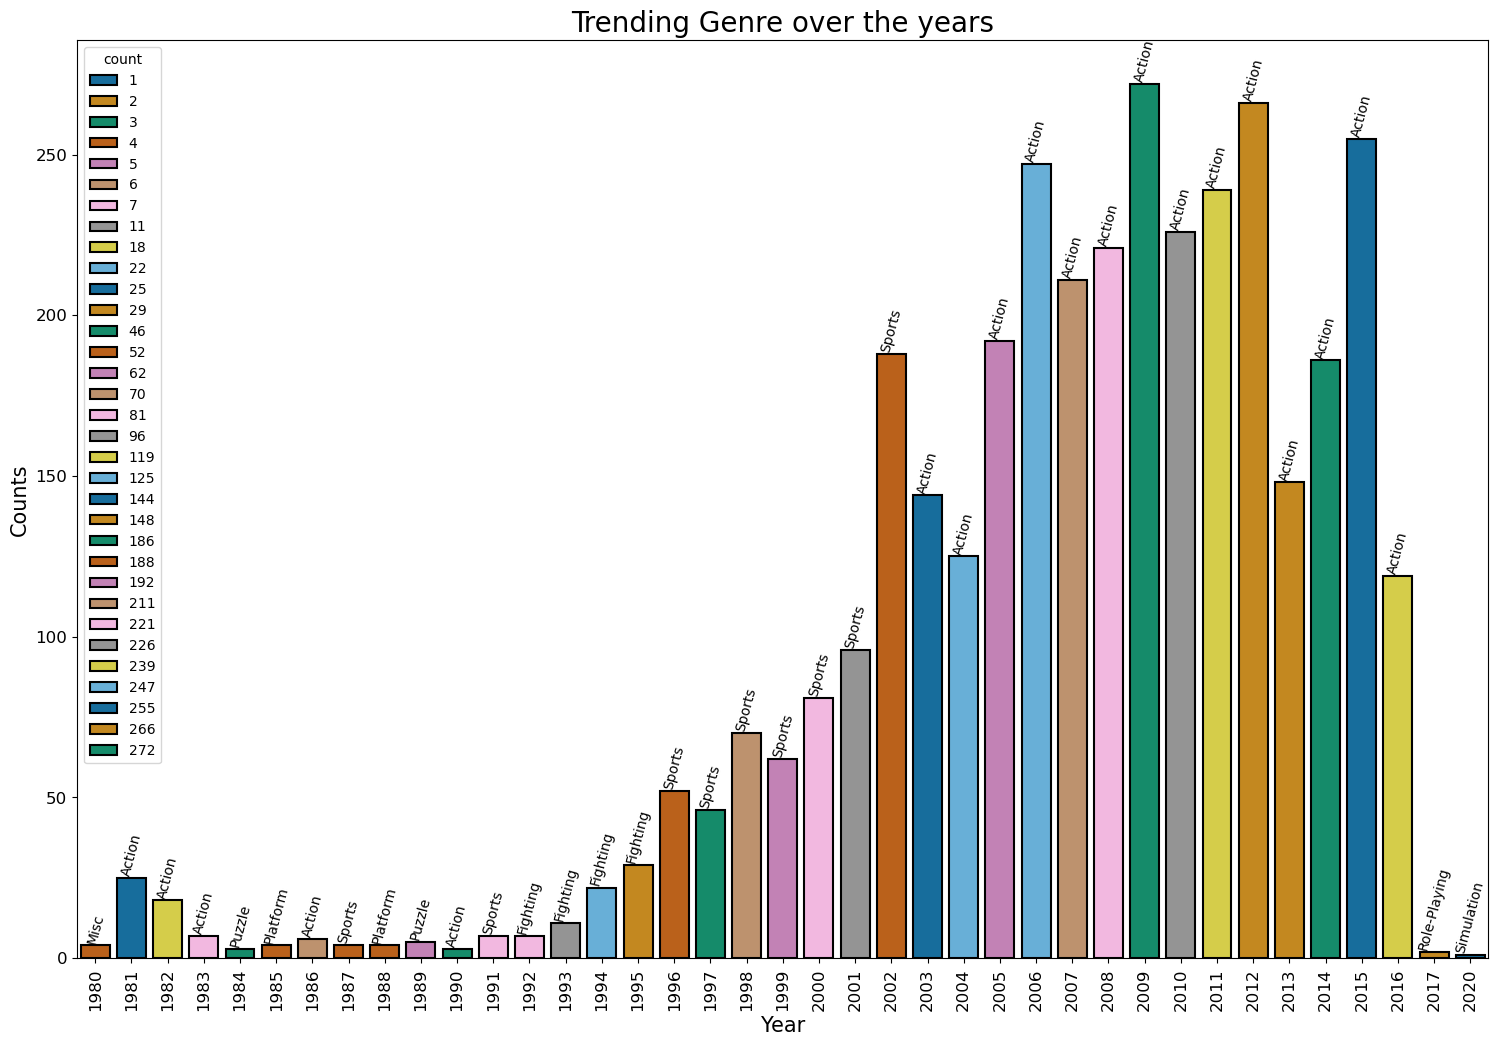

In [53]:
fig, ax = plt.subplots(figsize= (15, 10))

sns.barplot(x= top_genre_per_year["Year"],
            y= top_genre_per_year["count"],
            hue= top_genre_per_year["count"],
            palette= "colorblind",
            edgecolor = 'black',
            linewidth= 1.5)

for i, (year, genre) in enumerate(zip(top_genre_per_year["Year"], top_genre_per_year["Genre"])):
    plt.text(i, top_genre_per_year["count"].iloc[i] + 1, genre, ha='center', fontsize=10, rotation=75)


plt.tight_layout(),
plt.title('Trending Genre over the years', size= 20)
plt.xlabel("Year", size= 15)
plt.ylabel("Counts", size= 15)
plt.xticks(rotation= 90, size= 12)
plt.yticks(size= 12);

## Comparative Analysis: 
Compare sales performance of different gaming platforms (PlayStation, Xbox, Wii).


In [54]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [55]:
platform_sales = df.groupby("Platform")["Global_Sales"].sum().reset_index()
platform_sales.head()

,Platform,Global_Sales
0,2600,97.08
1,3DO,0.10
2,3DS,247.46
3,DC,15.97
4,DS,822.49


In [56]:
#df.loc[df['column_name'] == 'desired_value'].iloc[0]
PS_sales= platform_sales.loc[platform_sales["Platform"] == "PS"]
PS_sales

,Platform,Global_Sales
15,PS,730.66


In [57]:
Wii_sales= platform_sales.loc[platform_sales["Platform"] == "Wii"]
Wii_sales

,Platform,Global_Sales
26,Wii,926.71


In [58]:
XB_sales= platform_sales.loc[platform_sales["Platform"] == "XB"]
XB_sales

,Platform,Global_Sales
29,XB,258.26


In [59]:
frames = [PS_sales, Wii_sales, XB_sales]
result = pd.concat(frames).reset_index(drop= True)
result

,Platform,Global_Sales
0,PS,730.66
1,Wii,926.71
2,XB,258.26


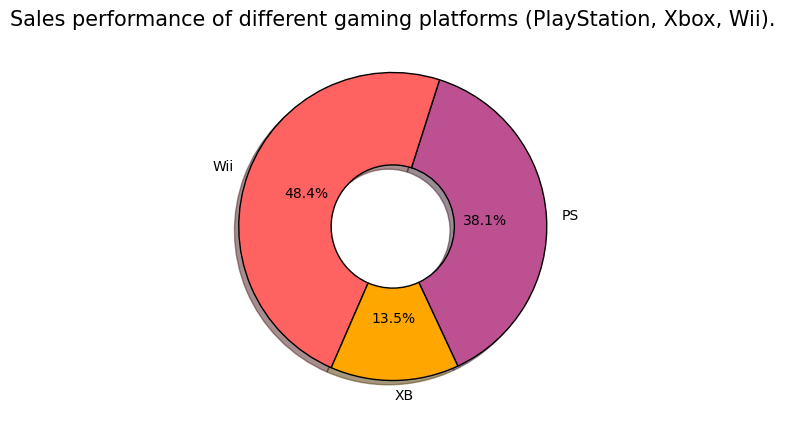

In [60]:
fig, ax= plt.subplots(figsize= (10, 5))

plt.pie(x= result["Global_Sales"], labels= result["Platform"],
       shadow= True,
       autopct= '%1.1f%%',
       colors=['#bc5090','#ff6361','#ffa600'],
       wedgeprops={'edgecolor': 'black', 'width': 0.6},
       startangle=-65)

plt.title("Sales performance of different gaming platforms (PlayStation, Xbox, Wii).", size= 15);